# check Langleys

In [2]:
import atmPy.radiation.retrievals.langley_calibration as atmlc
import atmPy.radiation.retrievals.spectral_irradiance as atmspec
import atmPy.aerosols.physics.column_optical_properties as atmcop
import helpers

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
reload(atmspec)
reload(atmspec.atmlangcalib)

<module 'atmPy.radiation.retrievals.langley_calibration' from '/Users/htelg/prog/atm-py/atmPy/radiation/retrievals/langley_calibration.py'>

In [5]:
prefix = '/Users/htelg'
version = '0.6' #this is wehere the langleys go
version_in = '0.2'
serialno = 648
"""
changes
-------
0.6
- with pwv cal retrieval
0.5 
- improved cosine-correction
0.4
- improved airmass
- improved coordinates and included altitude
0.3
- use cloud screening for cleaning
- removed 940 nm channel in langley cleaning!
0.2
- langleys out to 5 atm
"""
p2fld_lang = f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.langleys/v{version}'
fnlut = f'/Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_{serialno}.nc'
p2fld_lang, fnlut

('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6',
 '/Users/htelg/projects/mfrsr2pwv/data/pwd_od_lut_648.nc')

# 940 lut

In [6]:
ds_lut = xr.open_dataset(fnlut)
ds_lut = ds_lut.rename({'air_mass': 'airmass'})
ds_lut.attrs.update({'path2file': fnlut})

# create Langles

In [7]:
import atmPy.radiation.retrievals.spectral_irradiance as atmspir

In [8]:
lt = None#lt_pre_648 #None
p2fld = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025')

In [9]:
p2flist = list(p2fld.glob('*'))
p2flist.sort()

In [10]:
p2flist

[PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250925.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250926.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250927.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250928.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250929.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20250930.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_20251001.nc'),
 PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_mfrsr_cosinecorrected_2025100

In [11]:
'/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_cosinecorrected_20251018.nc'

'/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.2/2025/dav_cosinecorrected_20251018.nc'

### 20251018

In [12]:
%matplotlib inline

In [13]:
date = '1018'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'


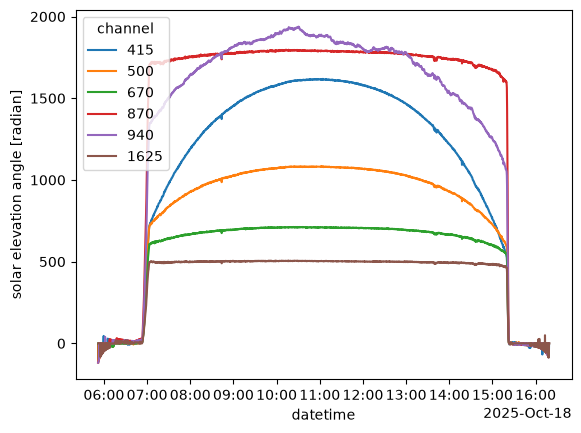

In [14]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [15]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [16]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.1238	 skewscale:2.4953
skewness: -0.0667	 skewscale:2.2670
skewness: 0.0918	 skewscale:2.3674
skewness: 0.1707	 skewscale:2.6828
skewness: 0.1360	 skewscale:2.5440
skewness: 0.1152	 skewscale:2.4606
skewness: 0.1079	 skewscale:2.4318
skewness: 0.0687	 skewscale:2.2747
skewness: 0.0518	 skewscale:2.2073


skewness: 0.0498	 skewscale:2.1994
skewness: 0.0585	 skewscale:2.2340
skewness: 0.0274	 skewscale:2.1095
skewness: 0.0120	 skewscale:2.0481
skewness: 0.0232	 skewscale:2.0930
skewness: -0.1751	 skewscale:2.7004
skewness: -0.1342	 skewscale:2.5368
skewness: -0.0965	 skewscale:2.3861
skewness: -0.0206	 skewscale:2.0825
skewness: -0.0288	 skewscale:2.1151
skewness: -0.0385	 skewscale:2.1538
skewness: -0.0295	 skewscale:2.1181


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

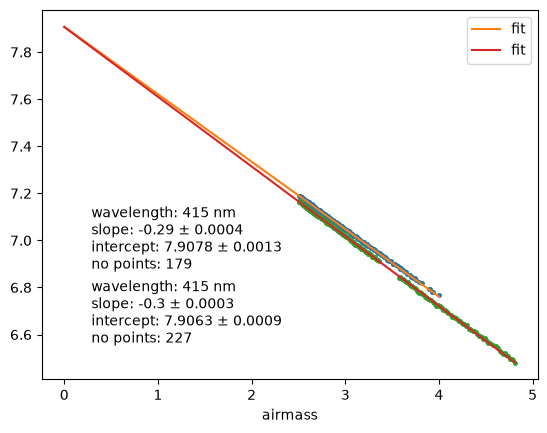

In [17]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

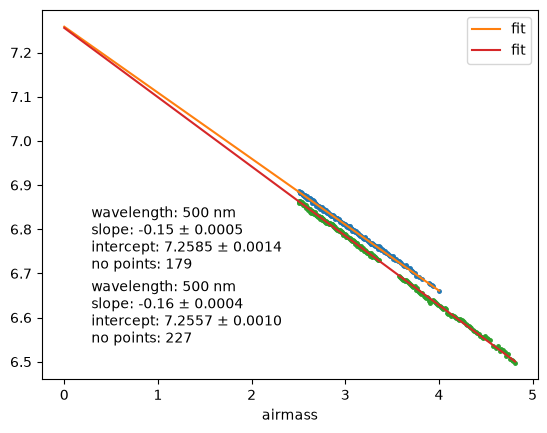

In [18]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

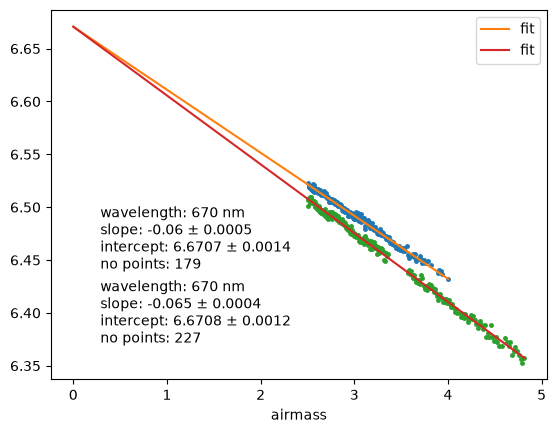

In [19]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

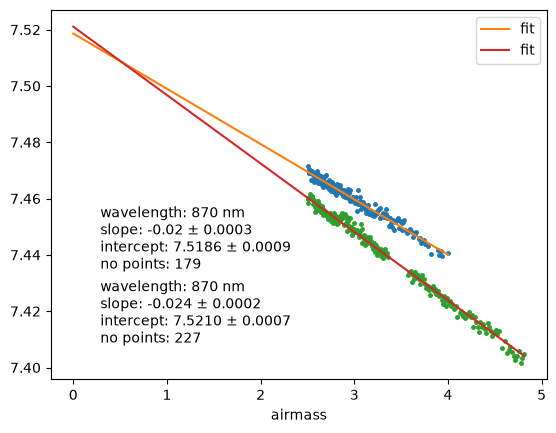

In [20]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

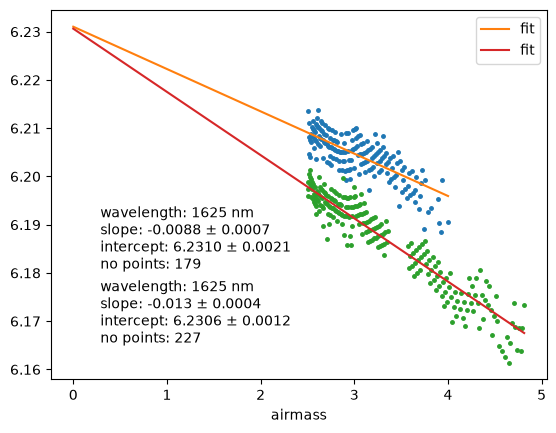

In [21]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [22]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251018.nc')

In [23]:
# p2out.unlink()

In [24]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251018.nc')

In [25]:
# p2out.unlink()

#### pwv

In [26]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

In [27]:
threshold = 3
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.0261	 skewscale:3.2347
skewness: -0.0459	 skewscale:3.4130
skewness: -0.0458	 skewscale:3.4118
skewness: -0.0558	 skewscale:3.5020
skewness: 0.0513	 skewscale:3.4618


(1115.3781702307247, 1900.0)

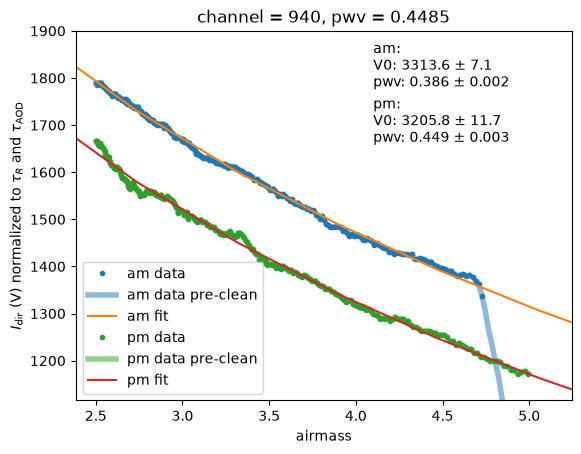

In [28]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1900)

In [29]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251018.nc')

In [30]:
# p2out.unlink()

In [31]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251018.nc')

In [32]:
# p2out.unlink()

### 20251017

In [33]:
%matplotlib inline

In [34]:
date = '1017'
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

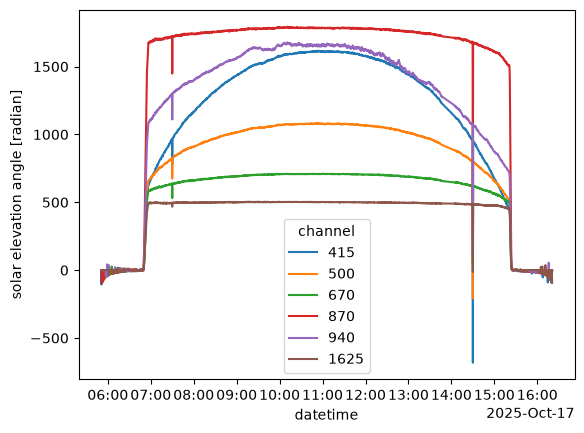

In [35]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [36]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [37]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.0396	 skewscale:2.1584
skewness: 0.0099	 skewscale:2.0394
skewness: 0.0105	 skewscale:2.0420
skewness: 0.0064	 skewscale:2.0257
skewness: -0.0075	 skewscale:2.0301
skewness: 0.0070	 skewscale:2.0280
skewness: -0.0006	 skewscale:2.0024
skewness: -0.0281	 skewscale:2.1122
skewness: 0.0100	 skewscale:2.0402
skewness: -0.0744	 skewscale:2.2976


skewness: -0.0763	 skewscale:2.3051


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

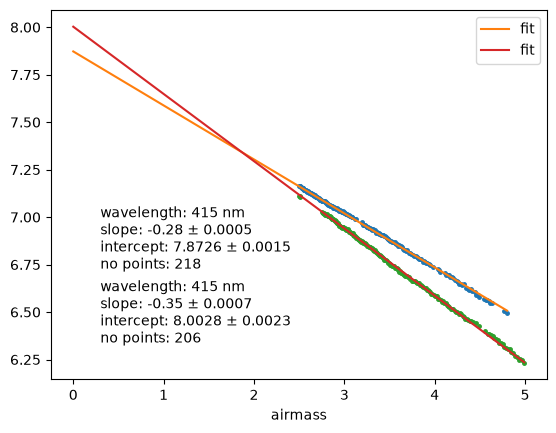

In [38]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

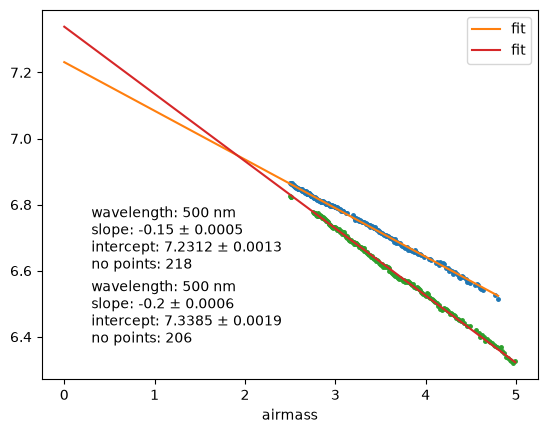

In [39]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

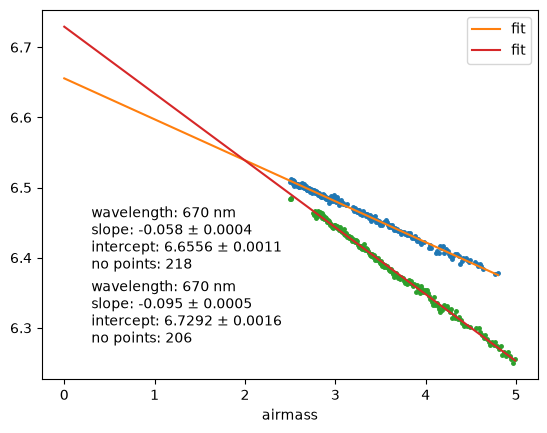

In [40]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

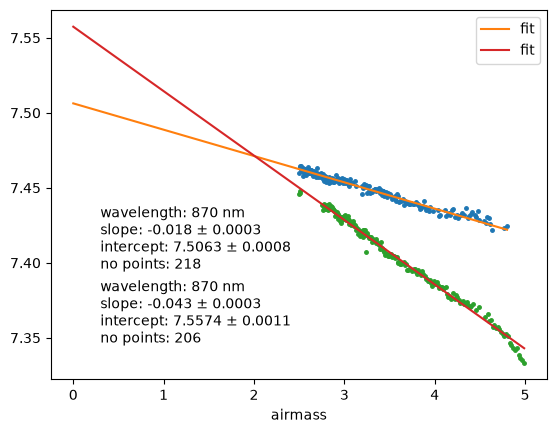

In [41]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

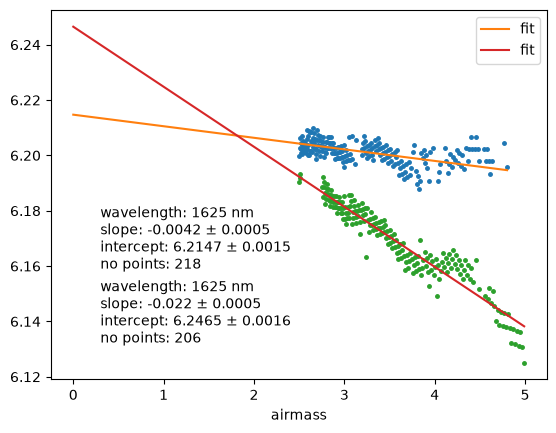

In [42]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [43]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251017.nc')

In [44]:
# p2out.unlink()

In [45]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251017.nc')

In [46]:
# p2out.unlink()

#### pwv

In [47]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

In [48]:
threshold = 3
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: 0.0791	 skewscale:3.7119
skewness: 0.1608	 skewscale:4.4475
skewness: -0.0559	 skewscale:3.5031
skewness: 0.0233	 skewscale:3.2096


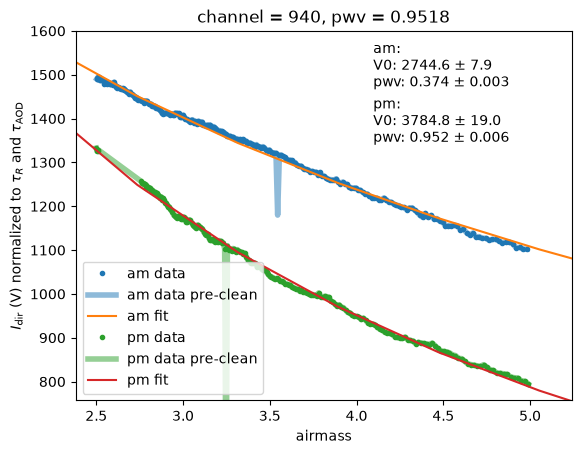

In [49]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1600)
a.legend(loc = 3)

In [50]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251017.nc')

In [51]:
# p2out.unlink()

In [52]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251017.nc')

In [53]:
# p2out.unlink()

### 20251016

In [54]:
%matplotlib inline

In [55]:
date = '1016'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

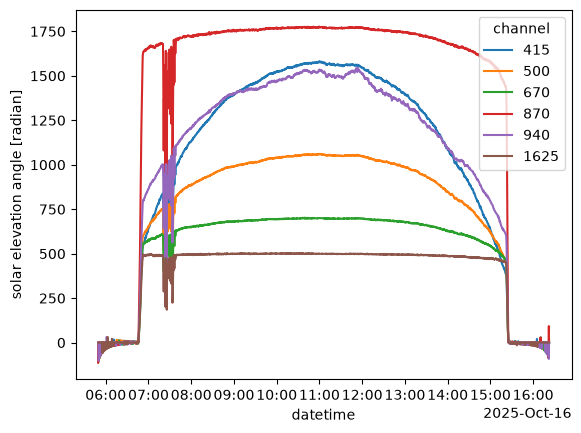

In [56]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [57]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [58]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.1375	 skewscale:2.5502
skewness: -0.1716	 skewscale:2.6864
skewness: -0.2131	 skewscale:2.8523
skewness: -0.1944	 skewscale:2.7776
skewness: -0.1333	 skewscale:2.5330
skewness: -0.0259	 skewscale:2.1037
skewness: 0.0206	 skewscale:2.0823
skewness: 0.0585	 skewscale:2.2340
skewness: 0.0660	 skewscale:2.2642
skewness: -0.2080	 skewscale:2.8322


skewness: -0.1543	 skewscale:2.6170
skewness: -0.1246	 skewscale:2.4983
skewness: -0.1145	 skewscale:2.4582
skewness: -0.0966	 skewscale:2.3863


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

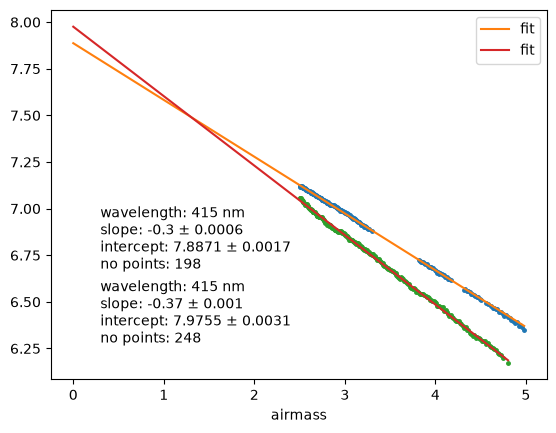

In [59]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

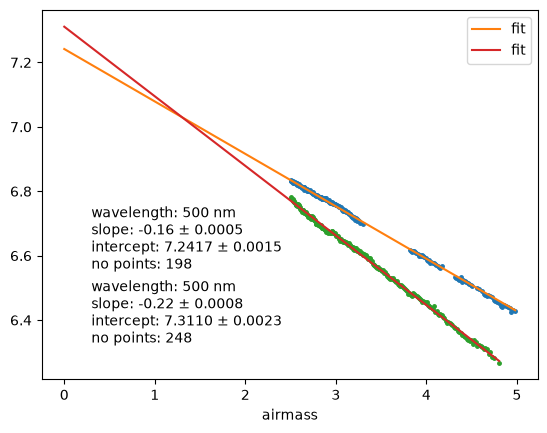

In [60]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

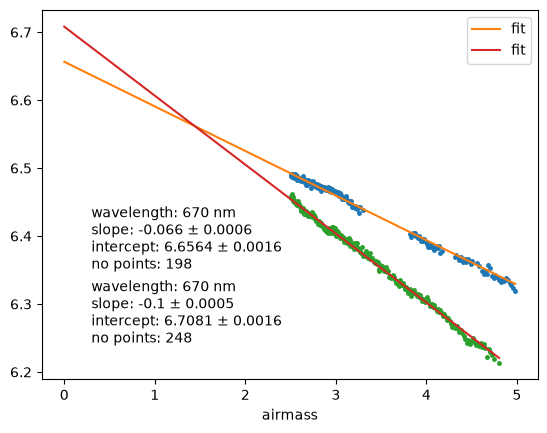

In [61]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

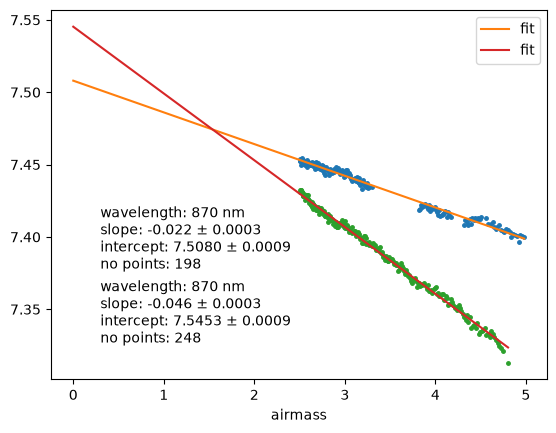

In [62]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

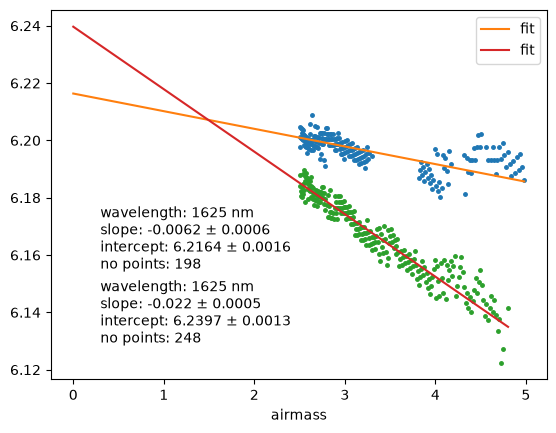

In [63]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [64]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251016.nc')

In [65]:
# p2out.unlink()

In [66]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251016.nc')

In [67]:
# p2out.unlink()

#### pwv

In [68]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.2807	 skewscale:3.1230
skewness: -0.2950	 skewscale:3.1801
skewness: -0.2806	 skewscale:3.1223
skewness: -0.2241	 skewscale:2.8965
skewness: -0.1440	 skewscale:2.5761


skewness: -0.0072	 skewscale:2.0288


skewness: 0.0649	 skewscale:2.2598


skewness: -0.0028	 skewscale:2.0113
skewness: -0.0194	 skewscale:2.0777
skewness: 0.0066	 skewscale:2.0265
skewness: -0.0039	 skewscale:2.0157
skewness: -0.0048	 skewscale:2.0192


skewness: -0.0102	 skewscale:2.0407
skewness: -0.0202	 skewscale:2.0806


skewness: -0.0037	 skewscale:2.0149
skewness: -0.0098	 skewscale:2.0393
skewness: 0.0208	 skewscale:2.0834


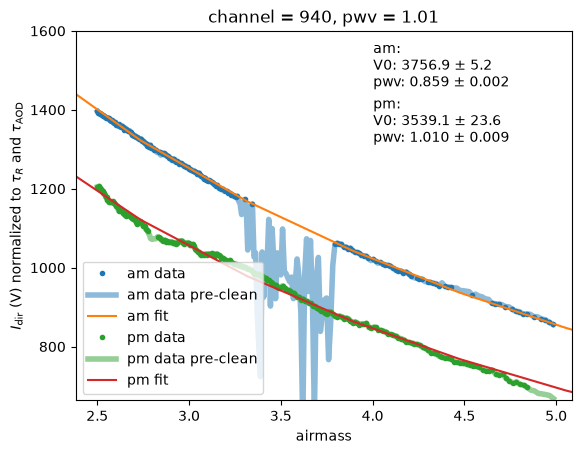

In [69]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1600)
a.legend(loc = 3)

In [70]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251016.nc')

In [71]:
# p2out.unlink()

In [72]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251016.nc')

In [73]:
# p2out.unlink()

### 20251015

In [74]:
%matplotlib inline

In [75]:
date = '1015'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

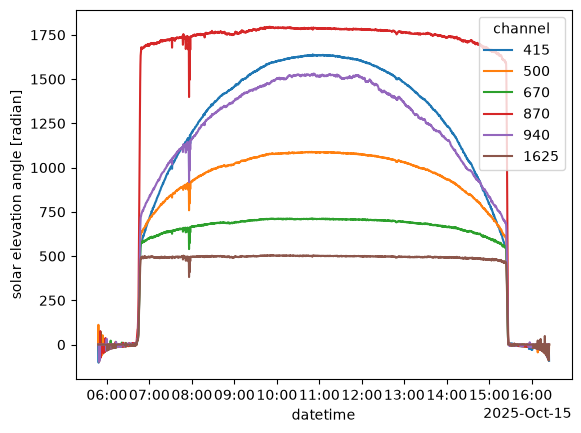

In [76]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [77]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [78]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.1428	 skewscale:2.5710
skewness: -0.1351	 skewscale:2.5405
skewness: -0.0058	 skewscale:2.0232
skewness: 0.0461	 skewscale:2.1842
skewness: 0.0555	 skewscale:2.2218
skewness: 0.0419	 skewscale:2.1677


skewness: 0.0323	 skewscale:2.1292
skewness: 0.0266	 skewscale:2.1064
skewness: 0.0476	 skewscale:2.1905
skewness: 0.0441	 skewscale:2.1763
skewness: 0.0245	 skewscale:2.0979
skewness: 0.0426	 skewscale:2.1705
skewness: 0.0423	 skewscale:2.1693
skewness: 0.1125	 skewscale:2.4500
skewness: 0.1182	 skewscale:2.4727


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

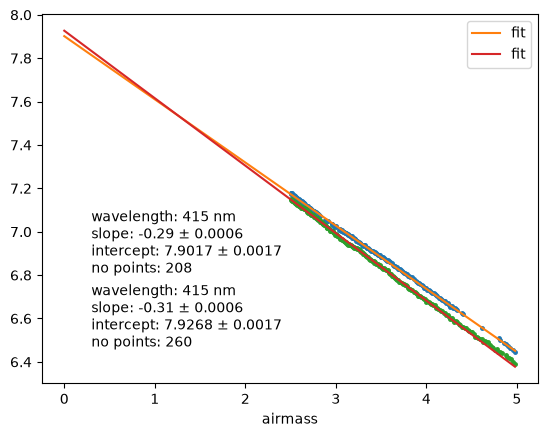

In [79]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

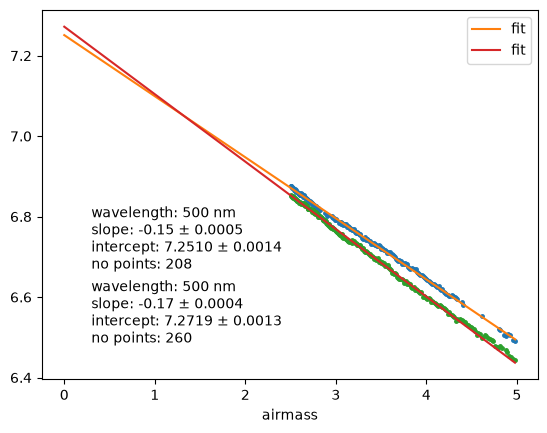

In [80]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

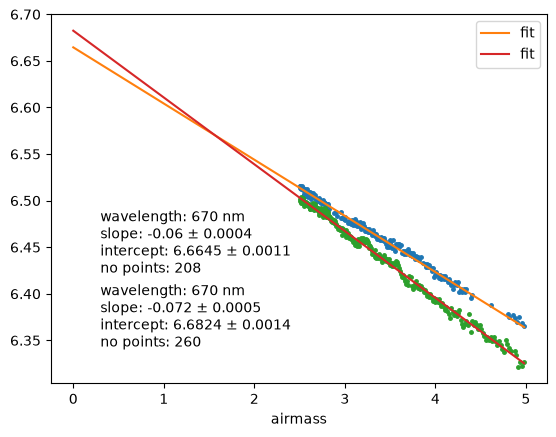

In [81]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

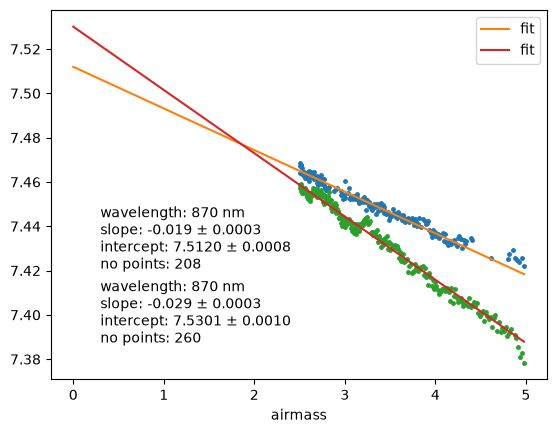

In [82]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

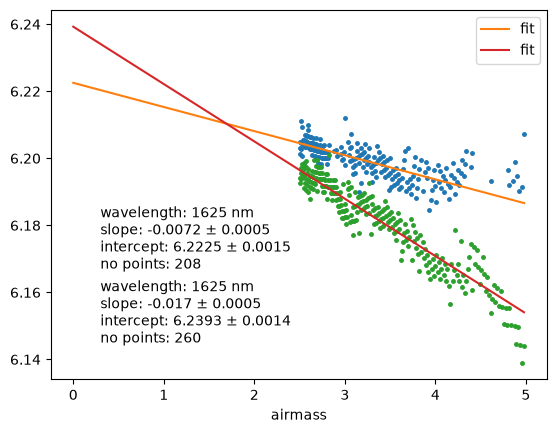

In [83]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [84]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251015.nc')

In [85]:
# p2out.unlink()

In [86]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251015.nc')

In [87]:
# p2out.unlink()

#### pwv

In [88]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.1410	 skewscale:2.5638
skewness: -0.1493	 skewscale:2.5972
skewness: -0.1325	 skewscale:2.5300
skewness: -0.1376	 skewscale:2.5505


skewness: 0.0895	 skewscale:2.3580


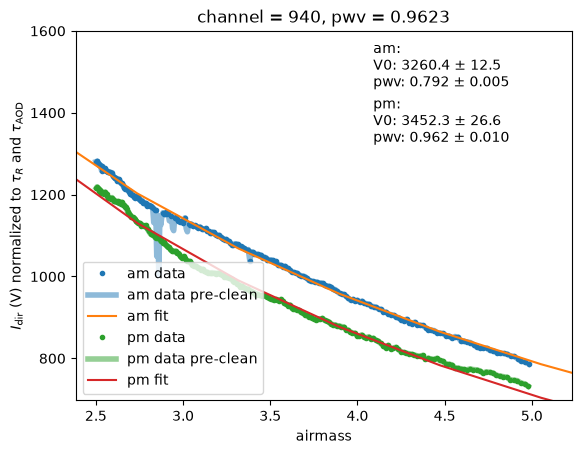

In [89]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1600)
a.legend(loc = 3)

In [90]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251015.nc')

In [91]:
# p2out.unlink()

In [92]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251015.nc')

In [93]:
# p2out.unlink()

### 20251014

In [94]:
%matplotlib inline

In [95]:
date = '1014'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

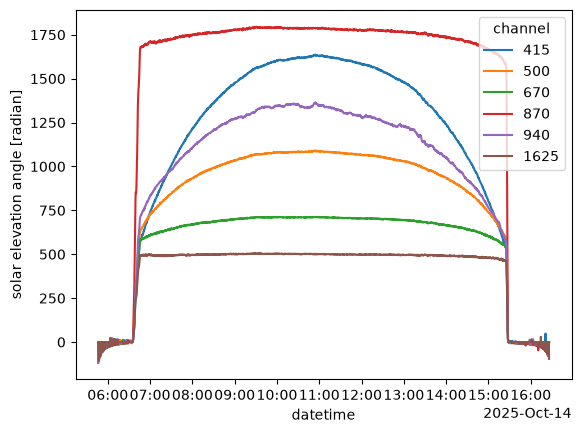

In [96]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [97]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [98]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: 0.2189	 skewscale:2.8755
skewness: 0.2170	 skewscale:2.8681
skewness: 0.2175	 skewscale:2.8698
skewness: 0.1715	 skewscale:2.6858
skewness: 0.0914	 skewscale:2.3657
skewness: 0.0573	 skewscale:2.2291
skewness: 0.0479	 skewscale:2.1915
skewness: 0.0500	 skewscale:2.1998


skewness: 0.0457	 skewscale:2.1829
skewness: 0.0462	 skewscale:2.1848
skewness: 0.0396	 skewscale:2.1584
skewness: 0.0467	 skewscale:2.1868
skewness: 0.0295	 skewscale:2.1178
skewness: 0.0200	 skewscale:2.0801
skewness: -0.0081	 skewscale:2.0324
skewness: -0.0195	 skewscale:2.0779
skewness: -0.0225	 skewscale:2.0900
skewness: -0.0185	 skewscale:2.0742
skewness: -0.0119	 skewscale:2.0475
skewness: 0.0157	 skewscale:2.0626
skewness: 0.0068	 skewscale:2.0274
skewness: -0.0073	 skewscale:2.0294
skewness: 0.0036	 skewscale:2.0142
skewness: 0.0008	 skewscale:2.0032


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

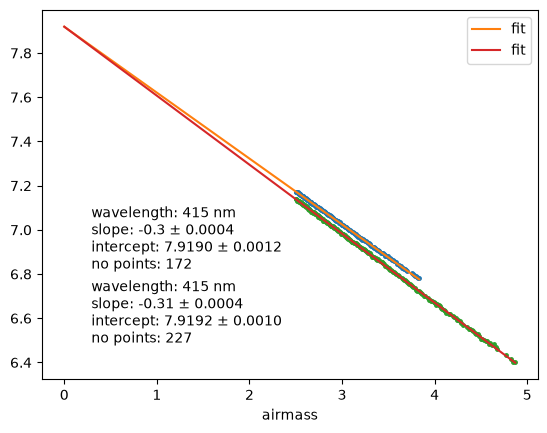

In [99]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

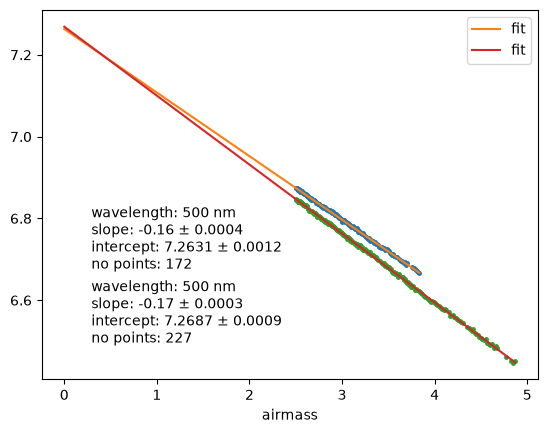

In [100]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

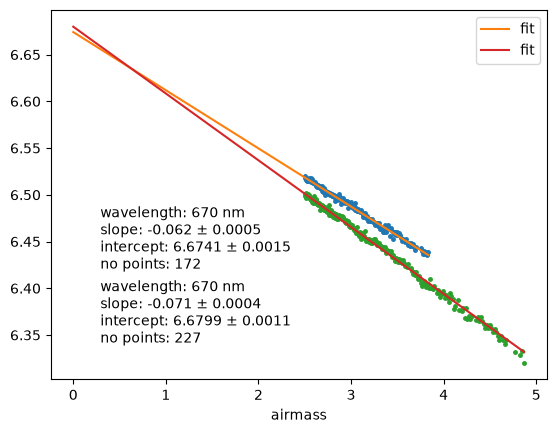

In [101]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

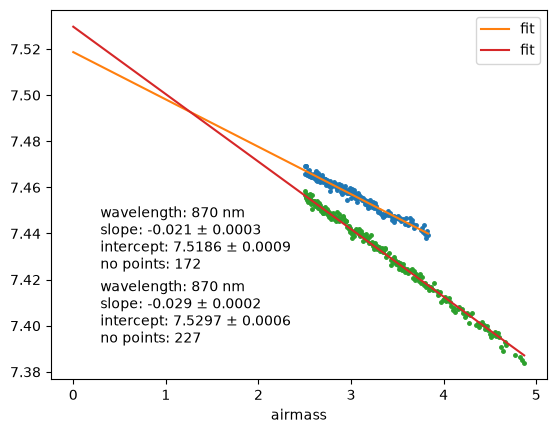

In [102]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

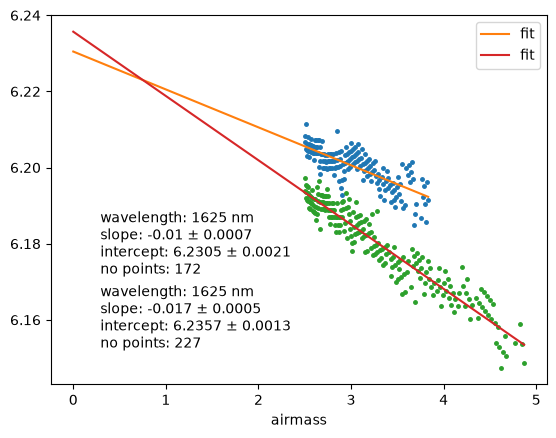

In [103]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [104]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251014.nc')

In [105]:
# p2out.unlink()

In [106]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251014.nc')

In [107]:
# p2out.unlink()

#### pwv

In [108]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.0380	 skewscale:2.1518
skewness: -0.0279	 skewscale:2.1116
skewness: -0.0282	 skewscale:2.1129
skewness: -0.0322	 skewscale:2.1288
skewness: -0.0725	 skewscale:2.2899
skewness: -0.0490	 skewscale:2.1962


skewness: -0.0337	 skewscale:2.1349


skewness: -0.0294	 skewscale:2.1174
skewness: -0.0484	 skewscale:2.1935


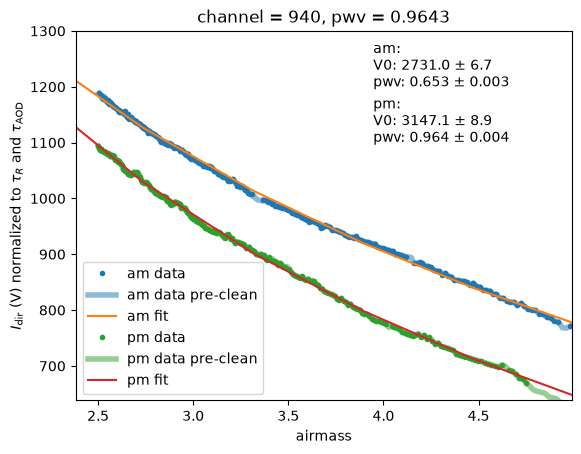

In [109]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1300)
a.legend(loc = 3)

In [110]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251014.nc')

In [111]:
# p2out.unlink()

In [112]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251014.nc')

In [113]:
# p2out.unlink()

### 20251013

In [114]:
%matplotlib inline

In [115]:
date = '1013'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

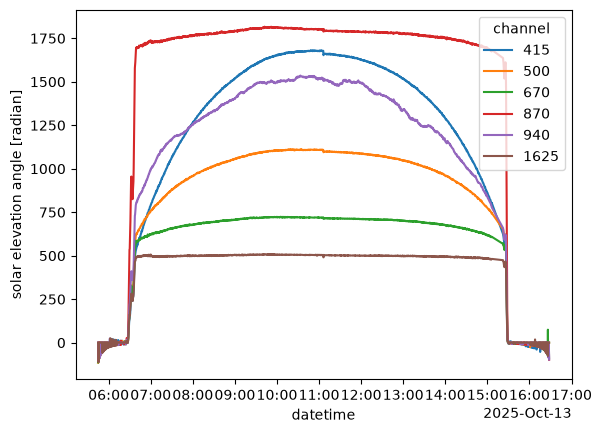

In [116]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [117]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [118]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: 0.1961	 skewscale:2.7845
skewness: 0.1925	 skewscale:2.7701
skewness: 0.2126	 skewscale:2.8502
skewness: 0.1782	 skewscale:2.7126
skewness: 0.1063	 skewscale:2.4252
skewness: 0.0554	 skewscale:2.2217
skewness: 0.0180	 skewscale:2.0719
skewness: 0.0196	 skewscale:2.0786
skewness: 0.0135	 skewscale:2.0542


skewness: 0.0063	 skewscale:2.0254
skewness: 0.0241	 skewscale:2.0963
skewness: 0.0482	 skewscale:2.1930
skewness: -0.0106	 skewscale:2.0422
skewness: 0.0625	 skewscale:2.2500
skewness: 0.0669	 skewscale:2.2675
skewness: 0.0451	 skewscale:2.1806
skewness: 0.0342	 skewscale:2.1369
skewness: 0.0207	 skewscale:2.0828
skewness: 0.0257	 skewscale:2.1029


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

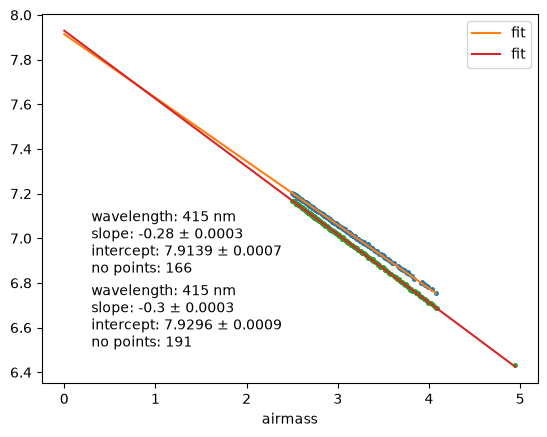

In [119]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

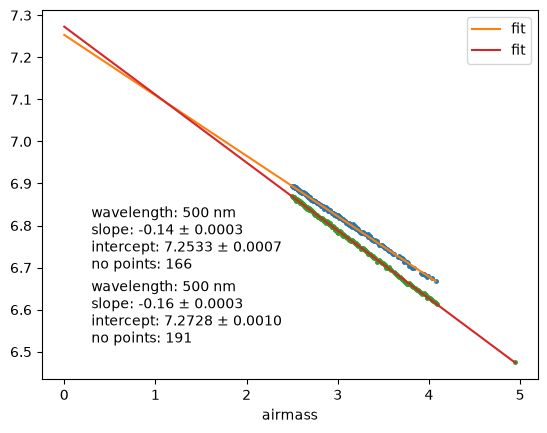

In [120]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

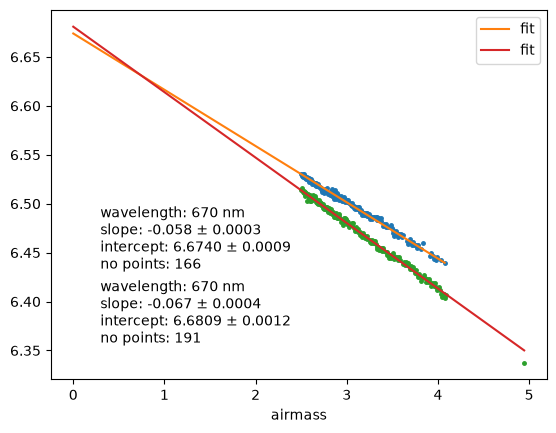

In [121]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

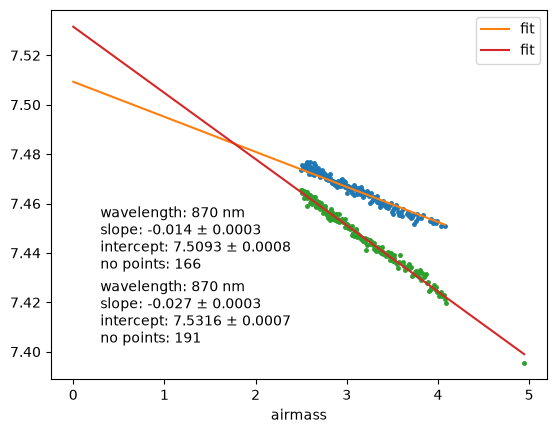

In [122]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

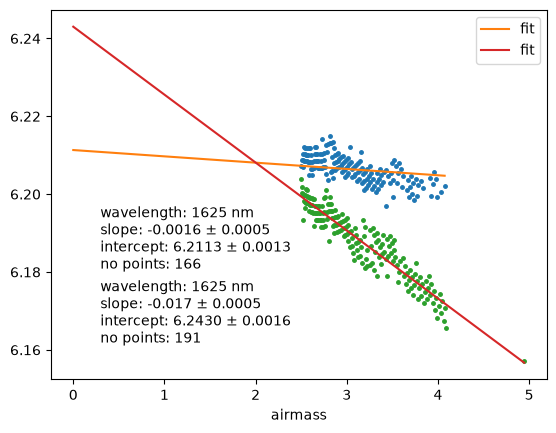

In [123]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [124]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251013.nc')

In [125]:
# p2out.unlink()

In [126]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251013.nc')

In [127]:
# p2out.unlink()

#### pwv

In [128]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: 0.2798	 skewscale:3.1192
skewness: -0.0566	 skewscale:2.2263
skewness: -0.0295	 skewscale:2.1180
skewness: -0.0240	 skewscale:2.0958


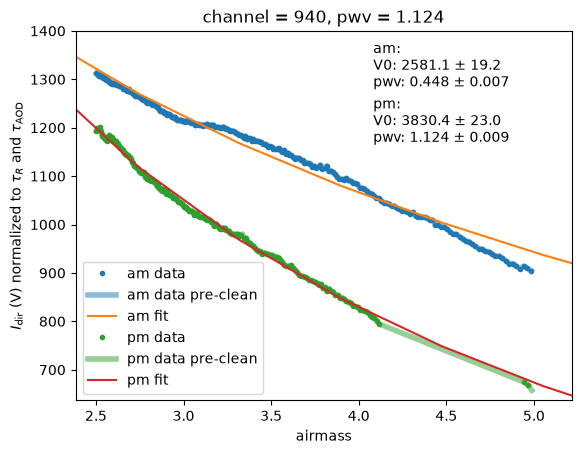

In [129]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1400)
a.legend(loc = 3)

In [130]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251013.nc')

In [131]:
# p2out.unlink()

In [132]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251013.nc')

In [133]:
# p2out.unlink()

### 20251012

In [134]:
%matplotlib inline

In [135]:
date = '1012'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

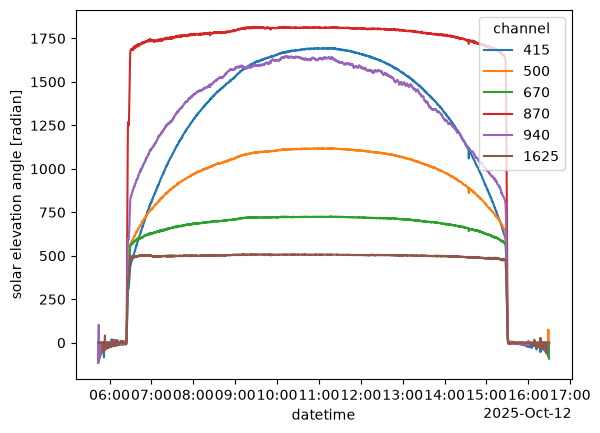

In [136]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [137]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [138]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: 0.1384	 skewscale:2.5538
skewness: 0.1667	 skewscale:2.6670
skewness: 0.0961	 skewscale:2.3843
skewness: -0.0125	 skewscale:2.0501
skewness: -0.0092	 skewscale:2.0370
skewness: -0.0298	 skewscale:2.1191
skewness: -0.0458	 skewscale:2.1831
skewness: 0.1613	 skewscale:2.6452
skewness: 0.2190	 skewscale:2.8760


skewness: 0.2138	 skewscale:2.8552
skewness: 0.2032	 skewscale:2.8129
skewness: 0.1777	 skewscale:2.7109
skewness: 0.1918	 skewscale:2.7672
skewness: 0.1828	 skewscale:2.7313
skewness: 0.1552	 skewscale:2.6210
skewness: 0.1059	 skewscale:2.4236
skewness: 0.0722	 skewscale:2.2886
skewness: 0.0494	 skewscale:2.1976
skewness: 0.0350	 skewscale:2.1400
skewness: 0.0530	 skewscale:2.2119


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

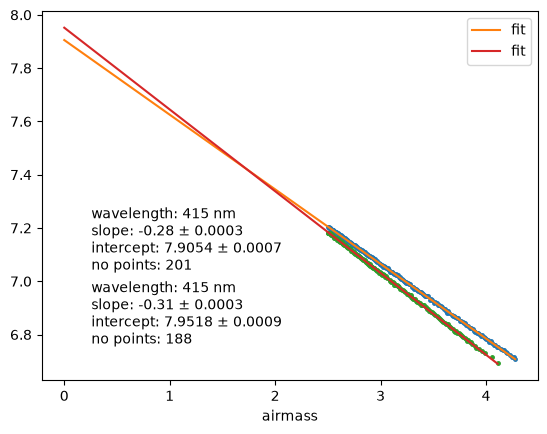

In [139]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

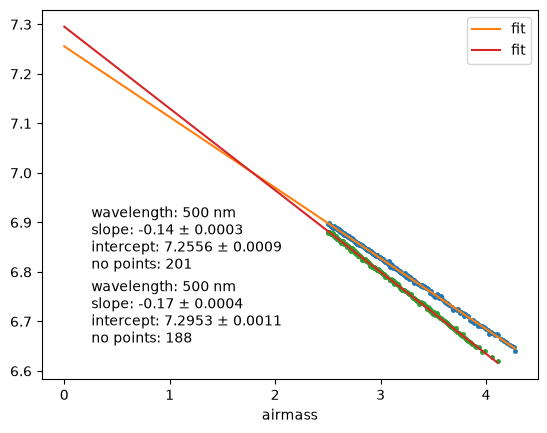

In [140]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

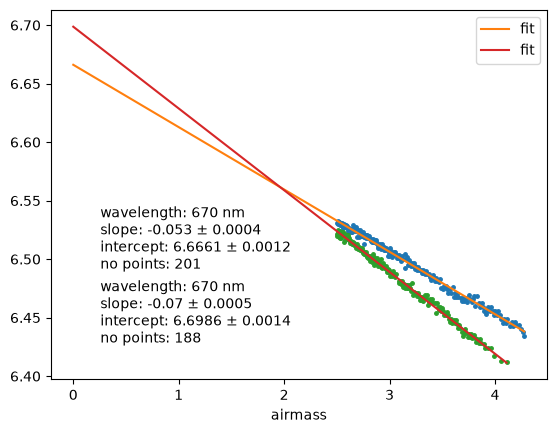

In [141]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

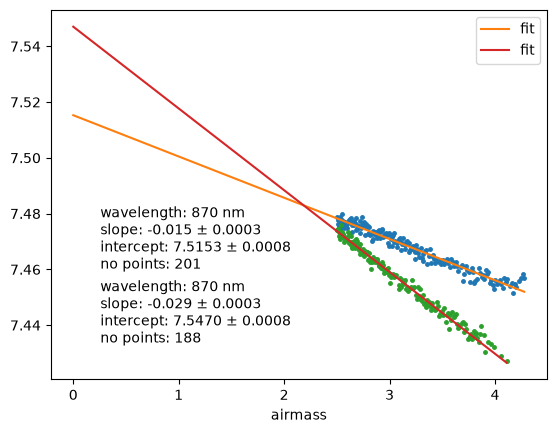

In [142]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

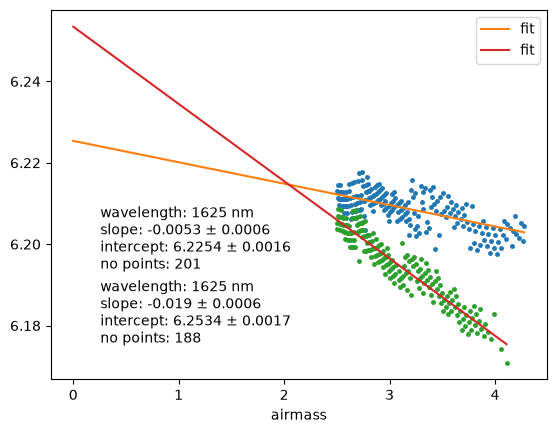

In [143]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [144]:
lang = lang_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True, parents=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_am_dav_mfrsr_cosinecorrected_20251012.nc')

In [145]:
# p2out.unlink()

In [146]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251012.nc')

In [147]:
# p2out.unlink()

#### pwv

In [148]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.0452	 skewscale:2.1809
skewness: -0.0176	 skewscale:2.0705
skewness: -0.0455	 skewscale:2.1819
skewness: -0.0160	 skewscale:2.0639
skewness: -0.0546	 skewscale:2.2185


skewness: -0.0877	 skewscale:2.3508


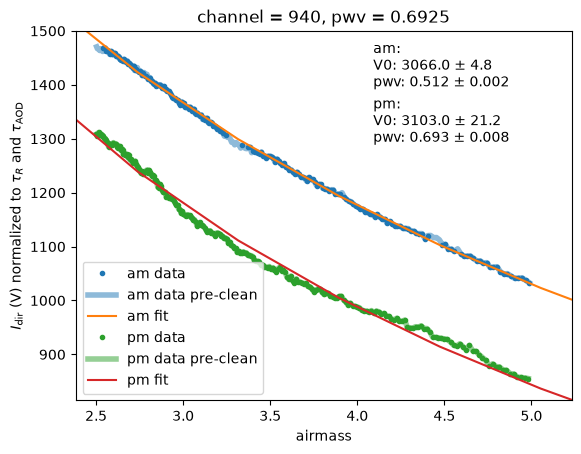

In [149]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1500)
a.legend(loc = 3)

In [150]:
pwvcal = pwvcal_am
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_am_dav_mfrsr_cosinecorrected_20251012.nc')

In [151]:
# p2out.unlink()

In [152]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251012.nc')

In [153]:
# p2out.unlink()

### 20251011

In [154]:
%matplotlib inline

In [155]:
date = '1011'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

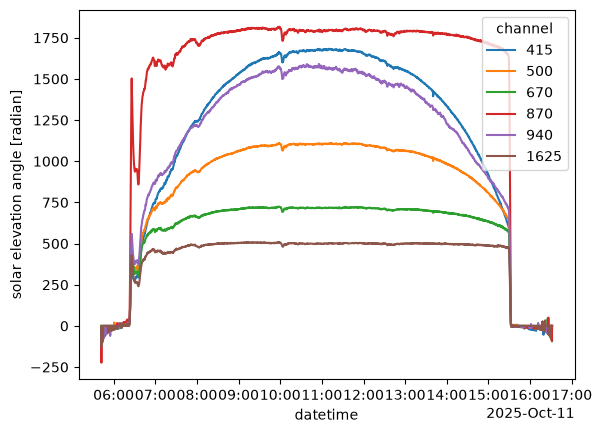

In [156]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [157]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------
Applying langley calibration
--------------------------------


In [158]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

skewness: -0.0683	 skewscale:2.2731
skewness: 0.0696	 skewscale:2.2783
skewness: 0.0654	 skewscale:2.2618
skewness: 0.0069	 skewscale:2.0278
skewness: 0.0175	 skewscale:2.0701
skewness: -0.0045	 skewscale:2.0182
skewness: 0.0162	 skewscale:2.0647


skewness: -0.0010	 skewscale:2.0039
skewness: -0.0173	 skewscale:2.0692
skewness: -0.0573	 skewscale:2.2293


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

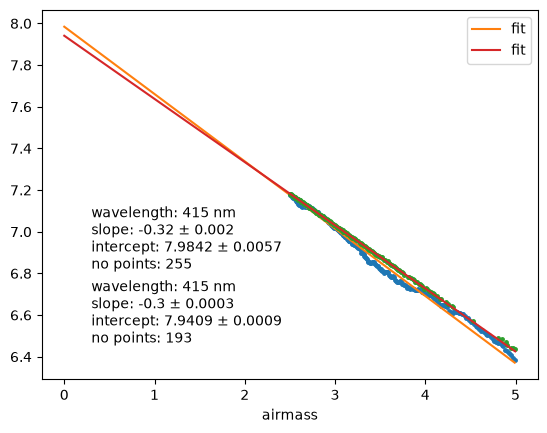

In [159]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

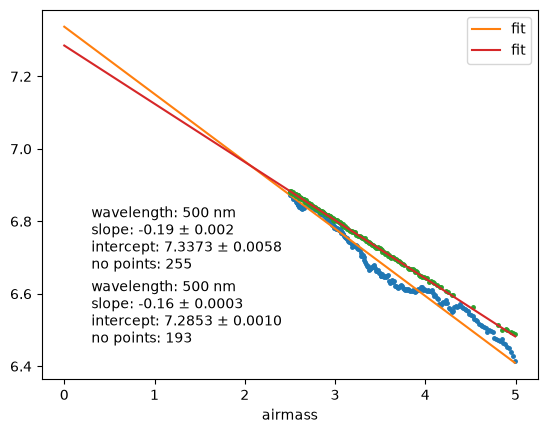

In [160]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

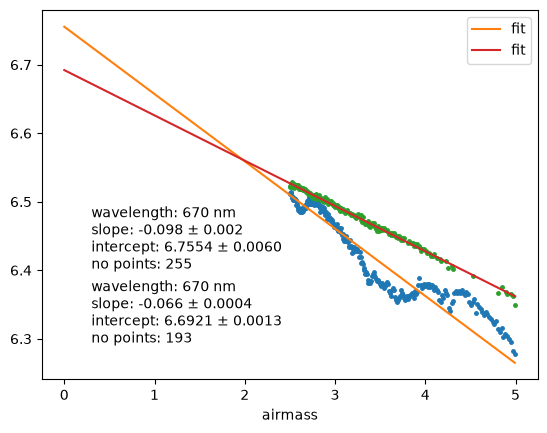

In [161]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

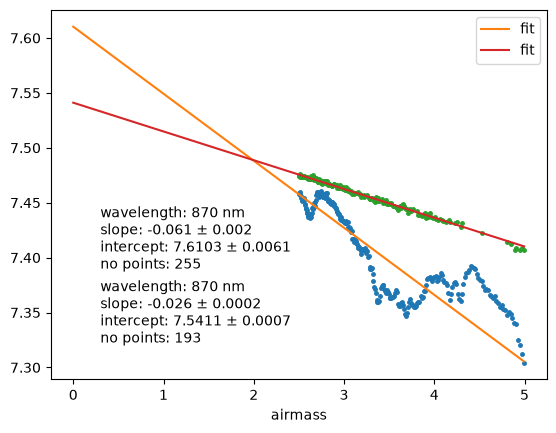

In [162]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='airmass'>)

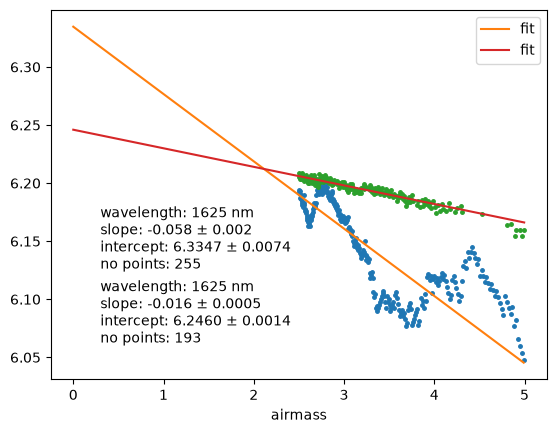

In [163]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [164]:
# lang = lang_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
# p2out.parent.mkdir(exist_ok=True, parents=True)
# if not p2out.is_file():
#     lang.save2netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out    

In [165]:
# p2out.unlink()

In [166]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/langley_pm_dav_mfrsr_cosinecorrected_20251011.nc')

In [167]:
# p2out.unlink()

#### pwv

In [168]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


skewness: -0.2671	 skewscale:3.0686
skewness: -0.0192	 skewscale:2.0769


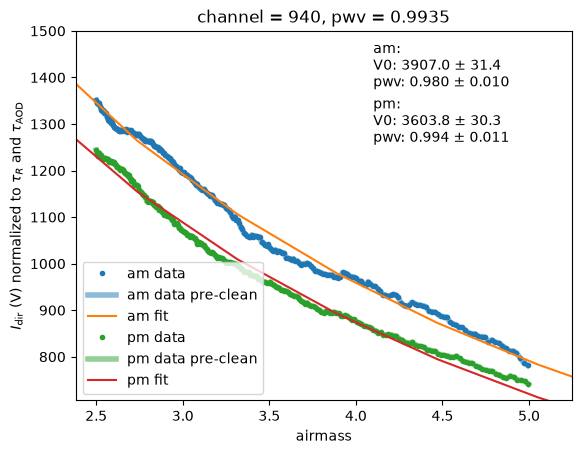

In [169]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1500)
a.legend(loc = 3)

In [170]:
# pwvcal = pwvcal_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
# if not p2out.is_file():
#     pwvcal.to_xarray().to_netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out 

In [171]:
# p2out.unlink()

In [172]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

File exist!!!


PosixPath('/Users/htelg/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.langleys/v0.6/pwvcal_pm_dav_mfrsr_cosinecorrected_20251011.nc')

In [173]:
# p2out.unlink()

### 20251002

In [174]:
data ='1002'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
# p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/648.cal/v0.1/frc_648_v0.1_20251002.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_20251002_preliminary.nc'
# lt = lt_pre_648

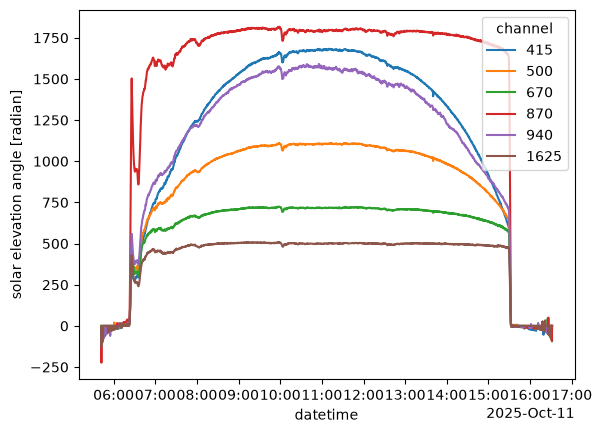

In [175]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [176]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------


ValueError: Ozone data is all none or zero! Try setting it with a constant value.

In [ ]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

In [ ]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

In [ ]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
# lang = lang_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
# p2out.parent.mkdir(exist_ok=True, parents=True)
# if not p2out.is_file():
#     lang.save2netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out    

In [ ]:
# p2out.unlink()

In [ ]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

In [ ]:
# p2out.unlink()

#### pwv

In [ ]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


In [ ]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1500)
a.legend(loc = 3)

In [ ]:
# pwvcal = pwvcal_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
# if not p2out.is_file():
#     pwvcal.to_xarray().to_netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out 

In [ ]:
# p2out.unlink()

In [ ]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

In [ ]:
# p2out.unlink()

### 20250928

In [177]:
date = '0928'
p2f = pl.Path(f'{prefix}/nfs/grad/Inst/MFR/Campaign/frc/2025/mfrsr/{serialno}.cal/v{version_in}/2025/dav_mfrsr_cosinecorrected_2025{date}.nc')
fnmet = f'{prefix}/nfs/grad/campaign/frc/2025/MetaData.netcdf/frc-vi_metadata_2025{date}_preliminary.nc'

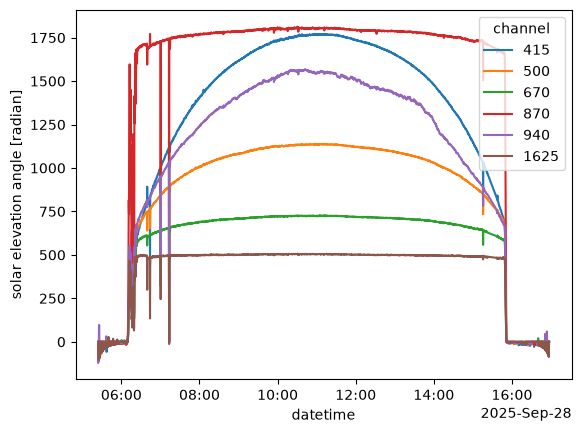

In [178]:
# first glance
f,a = plt.subplots()
ds = xr.open_dataset(p2f)
ds.direct_normal.plot.line(x = 'datetime', ax = a)
# at = a.twinx()
# cm.plot(ax= at)

In [179]:
out = helpers.get_langleys(ds, fnmet, 
                                        # None,
                                        lt,     
                                        langley_airmass_limits=(2.5, 5),
                                        clean = False,
                                        ds_lut = ds_lut,
                                        # test = True
                                       )

Applying langley calibration
--------------------------------


AssertionError: 

In [ ]:
lang_am = out['langley_am']
lang_pm = out['langley_pm']


if 1:
    lang_am.langleys = lang_am.langleys.dropna()
    
    lang_am = lang_am.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']
if 1:
    lang_pm.langleys = lang_pm.langleys.dropna()
    
    lang_pm = lang_pm.clean(threshold=2, 
                  # use_channels=[500,]
                 )['langley']

In [ ]:
wl = 415
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, 
             ax = a
            )

In [ ]:
wl = 500
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 670
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 870
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
wl = 1625
f,a = lang_am.plot(wavelength=wl, show_pre_clean=False, textpos=[0.1, 0.3])
lang_pm.plot(wavelength = wl, show_pre_clean= False, ax = a)

In [ ]:
# lang = lang_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
# p2out.parent.mkdir(exist_ok=True, parents=True)
# if not p2out.is_file():
#     lang.save2netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out    

In [ ]:
# p2out.unlink()

In [ ]:
lang = lang_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'langley_{lang.when}_{p2f.name}')
p2out.parent.mkdir(exist_ok=True)
if not p2out.is_file():
    lang.save2netcdf(p2out)
else:
    print('File exist!!!')
p2out    

In [ ]:
# p2out.unlink()

#### pwv

In [ ]:
pwvcal_am = out['pwvcal_am']
pwvcal_pm = out['pwvcal_pm']

threshold = 2
pwvcal_am = pwvcal_am.clean(threshold=threshold)['pwvcal']
pwvcal_pm = pwvcal_pm.clean(threshold=threshold)['pwvcal']


In [ ]:
f,a = plt.subplots()
pwvcal_am.plot(ax = a, label='am', textpos=(0.6,0.85))
pwvcal_pm.plot(ax = a, label='pm', textpos=(0.6,0.7))
a.set_ylim(top = 1500)
a.legend(loc = 3)

In [ ]:
# pwvcal = pwvcal_am
# p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
# if not p2out.is_file():
#     pwvcal.to_xarray().to_netcdf(p2out)
# else:
#     print('File exist!!!')
# p2out 

In [ ]:
# p2out.unlink()

In [ ]:
pwvcal = pwvcal_pm
p2out = pl.Path(p2fld_lang.format(serialno = serialno, version = version)).joinpath(f'pwvcal_{pwvcal.ampm}_{p2f.name}')
if not p2out.is_file():
    pwvcal.to_xarray().to_netcdf(p2out)
else:
    print('File exist!!!')
p2out 

In [ ]:
# p2out.unlink()